### 1. Setup and Data Generation

First, we'll import the necessary libraries and generate a synthetic dataset for classification. We'll use `make_classification` from `sklearn.datasets` for this purpose, as it allows us to easily create a separable dataset suitable for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Generate a synthetic dataset
X, y = make_classification(
    n_samples=300,        # Number of samples
    n_features=2,         # Number of features (for 2D visualization)
    n_informative=2,      # Number of informative features
    n_redundant=0,        # Number of redundant features
    n_repeated=0,         # Number of repeated features
    n_classes=2,          # Number of classes
    n_clusters_per_class=1, # Number of clusters per class
    random_state=42,      # For reproducibility
    flip_y=0.1            # Some noise in the labels
)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dataset generated. X_train shape:", X_train.shape, "y_train shape:", y_train.shape)

Dataset generated. X_train shape: (210, 2) y_train shape: (210,)


### 2. Preprocessing: Standard Scaling

It's crucial to scale the features before training SVMs, especially when using distance-based kernels like RBF, to ensure that all features contribute equally to the distance calculation.

In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


### 3. Individual SVM Base Learners

We will create three individual SVM classifiers, each with a different kernel: RBF, Polynomial (degree 3), and Linear. We set `probability=True` for soft voting in the ensemble.

In [3]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_poly = SVC(kernel='poly', degree=3, probability=True, random_state=42)
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

# Train individual SVMs
svm_rbf.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_linear.fit(X_train_scaled, y_train)

print("Individual SVMs trained.")

Individual SVMs trained.


### 4. Ensemble Method: VotingClassifier

Now, we'll combine these three base learners using a `VotingClassifier` with `voting='soft'`. Soft voting uses predicted probabilities to weigh each classifier's vote, which often leads to better performance than hard voting.

In [4]:
ensemble_clf = VotingClassifier(
    estimators=[
        ('rbf_svm', svm_rbf),
        ('poly_svm', svm_poly),
        ('linear_svm', svm_linear)
    ],
    voting='soft', # Use soft voting based on probabilities
    weights=[1, 1, 1] # Equal weight for each classifier
)

ensemble_clf.fit(X_train_scaled, y_train)

print("Ensemble VotingClassifier trained.")

Ensemble VotingClassifier trained.


### 5. Visualization: Decision Boundaries

This function will plot the decision boundaries of the classifiers. It creates a meshgrid over the feature space and predicts the class for each point to draw contours.

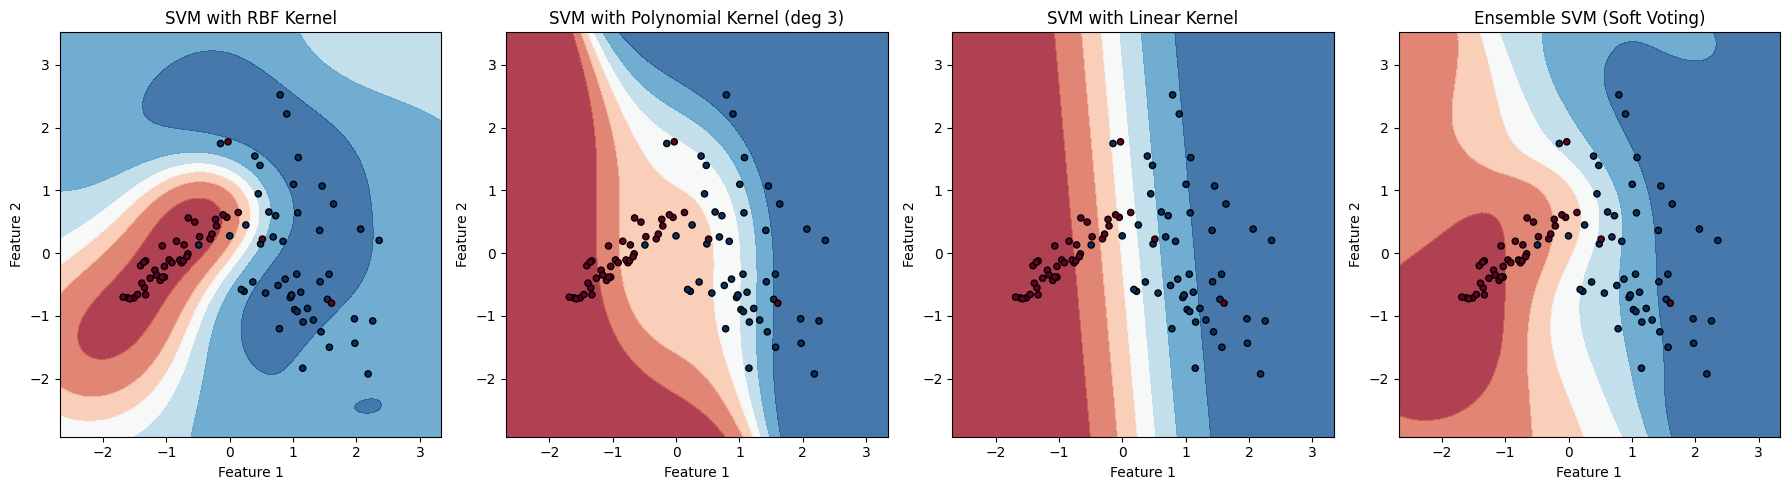

Decision boundary plots generated.


In [5]:
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict probabilities for soft voting, or classes for hard voting/single classifiers
    if hasattr(clf, "predict_proba"):
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k', cmap=plt.cm.RdBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plot_decision_boundary(svm_rbf, X_test_scaled, y_test, 'SVM with RBF Kernel')

plt.subplot(1, 4, 2)
plot_decision_boundary(svm_poly, X_test_scaled, y_test, 'SVM with Polynomial Kernel (deg 3)')

plt.subplot(1, 4, 3)
plot_decision_boundary(svm_linear, X_test_scaled, y_test, 'SVM with Linear Kernel')

plt.subplot(1, 4, 4)
plot_decision_boundary(ensemble_clf, X_test_scaled, y_test, 'Ensemble SVM (Soft Voting)')

plt.tight_layout()
plt.show()

print("Decision boundary plots generated.")

### 6. Evaluation

Finally, we evaluate the performance of the ensemble model using a classification report and accuracy score on the test set.

In [6]:
y_pred_ensemble = ensemble_clf.predict(X_test_scaled)

print("\n--- Ensemble Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble))
print("Accuracy Score:", accuracy_score(y_test, y_pred_ensemble))

# Optional: Evaluate individual models for comparison
print("\n--- Individual Model Accuracy ---")
print("RBF SVM Accuracy:", accuracy_score(y_test, svm_rbf.predict(X_test_scaled)))
print("Poly SVM Accuracy:", accuracy_score(y_test, svm_poly.predict(X_test_scaled)))
print("Linear SVM Accuracy:", accuracy_score(y_test, svm_linear.predict(X_test_scaled)))


--- Ensemble Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        41
           1       0.94      0.94      0.94        49

    accuracy                           0.93        90
   macro avg       0.93      0.93      0.93        90
weighted avg       0.93      0.93      0.93        90

Accuracy Score: 0.9333333333333333

--- Individual Model Accuracy ---
RBF SVM Accuracy: 0.9333333333333333
Poly SVM Accuracy: 0.8222222222222222
Linear SVM Accuracy: 0.9222222222222223
